# Blinkit Sales Analytics Project

## 1. Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset


In [5]:


orders = pd.read_csv("../data/raw/blinkit_orders.csv")
order_items = pd.read_csv("../data/raw/blinkit_order_items.csv")
products = pd.read_csv("../data/raw/blinkit_products.csv")

print("Orders Shape:", orders.shape)
print("Order Items Shape:", order_items.shape)
print("Products Shape:", products.shape)

Orders Shape: (5000, 10)
Order Items Shape: (5000, 4)
Products Shape: (268, 10)


## 3. Dataset Overview

In [6]:
# Orders Table Overview

print("=" * 50)
print("ORDERS DATASET")
print("=" * 50)

display(orders.head())

print("\nShape:", orders.shape)

print("\nColumns:")
print(orders.columns.tolist())

print("\nData Types:")
display(orders.dtypes)

print("\nMissing Values:")
display(orders.isnull().sum())

ORDERS DATASET


,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id
0,1961864118,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771
1,1549769649,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534
2,9185164487,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886
3,9644738826,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917
4,5427684290,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741



Shape: (5000, 10)

Columns:
['order_id', 'customer_id', 'order_date', 'promised_delivery_time', 'actual_delivery_time', 'delivery_status', 'order_total', 'payment_method', 'delivery_partner_id', 'store_id']

Data Types:


order_id                    int64
customer_id                 int64
order_date                    str
promised_delivery_time        str
actual_delivery_time          str
delivery_status               str
order_total               float64
payment_method                str
delivery_partner_id         int64
store_id                    int64
dtype: object


Missing Values:


order_id                  0
customer_id               0
order_date                0
promised_delivery_time    0
actual_delivery_time      0
delivery_status           0
order_total               0
payment_method            0
delivery_partner_id       0
store_id                  0
dtype: int64

In [7]:
# Order Items Overview

print("=" * 50)
print("ORDER ITEMS DATASET")
print("=" * 50)

display(order_items.head())

print("\nShape:", order_items.shape)

print("\nColumns:")
print(order_items.columns.tolist())

print("\nMissing Values:")
display(order_items.isnull().sum())

ORDER ITEMS DATASET


,order_id,product_id,quantity,unit_price
0,1961864118,642612,3,517.03
1,1549769649,378676,1,881.42
2,9185164487,741341,2,923.84
3,9644738826,561860,1,874.78
4,5427684290,602241,2,976.55



Shape: (5000, 4)

Columns:
['order_id', 'product_id', 'quantity', 'unit_price']

Missing Values:


order_id      0
product_id    0
quantity      0
unit_price    0
dtype: int64

In [8]:
# Products Overview

print("=" * 50)
print("PRODUCTS DATASET")
print("=" * 50)

display(products.head())

print("\nShape:", products.shape)

print("\nColumns:")
print(products.columns.tolist())

print("\nMissing Values:")
display(products.isnull().sum())

PRODUCTS DATASET


,product_id,product_name,category,brand,price,mrp,margin_percentage,shelf_life_days,min_stock_level,max_stock_level
0,153019,Onions,Fruits & Vegetables,Aurora LLC,947.95,1263.93,25.0,3,13,88
1,11422,Potatoes,Fruits & Vegetables,Ramaswamy-Tata,127.16,169.55,25.0,3,20,65
2,669378,Potatoes,Fruits & Vegetables,Chadha and Sons,212.14,282.85,25.0,3,23,70
3,848226,Tomatoes,Fruits & Vegetables,Barad and Sons,209.59,279.45,25.0,3,10,51
4,890623,Onions,Fruits & Vegetables,"Sangha, Nagar and Varty",354.52,472.69,25.0,3,27,55



Shape: (268, 10)

Columns:
['product_id', 'product_name', 'category', 'brand', 'price', 'mrp', 'margin_percentage', 'shelf_life_days', 'min_stock_level', 'max_stock_level']

Missing Values:


product_id           0
product_name         0
category             0
brand                0
price                0
mrp                  0
margin_percentage    0
shelf_life_days      0
min_stock_level      0
max_stock_level      0
dtype: int64

In [9]:
# Orders Table Details

display(orders.head(10))

,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id
0,1961864118,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771
1,1549769649,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534
2,9185164487,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886
3,9644738826,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917
4,5427684290,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741
5,3265154092,43367112,2023-03-18 16:29:51,2023-03-18 16:49:51,2023-03-18 16:48:51,On Time,3161.43,UPI,554,3442
6,4898355547,13284996,2023-04-16 18:50:37,2023-04-16 19:01:37,2023-04-16 19:02:37,On Time,956.40,Card,14630,1318
7,6568151549,88866835,2024-03-31 06:26:48,2024-03-31 06:37:48,2024-03-31 06:39:48,On Time,905.47,Cash,67714,115
8,6006693867,24496983,2023-07-13 23:49:36,2023-07-14 00:02:36,2023-07-14 00:05:36,On Time,1371.17,Card,91362,9021
9,374186990,52215833,2023-08-09 01:17:30,2023-08-09 01:37:30,2023-08-09 01:44:30,Slightly Delayed,1601.19,Wallet,77203,7955


In [10]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                5000 non-null   int64  
 1   customer_id             5000 non-null   int64  
 2   order_date              5000 non-null   str    
 3   promised_delivery_time  5000 non-null   str    
 4   actual_delivery_time    5000 non-null   str    
 5   delivery_status         5000 non-null   str    
 6   order_total             5000 non-null   float64
 7   payment_method          5000 non-null   str    
 8   delivery_partner_id     5000 non-null   int64  
 9   store_id                5000 non-null   int64  
dtypes: float64(1), int64(4), str(5)
memory usage: 390.8 KB


In [11]:
orders.describe(include="all")


,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id
count,5.000000e+03,5.000000e+03,5000,5000,5000,5000,5000.00000,5000,5000.000000,5000.000000
unique,NaN,NaN,5000,4999,5000,3,NaN,4,NaN,NaN
top,NaN,NaN,2024-07-17 08:34:01,2024-10-13 14:06:50,2024-07-17 08:47:01,On Time,NaN,Card,NaN,NaN
freq,NaN,NaN,1,2,1,3470,NaN,1285,NaN,NaN
mean,5.029129e+09,5.009685e+07,NaN,NaN,NaN,NaN,2201.86170,NaN,50050.318200,4999.689000
std,2.863533e+09,2.919082e+07,NaN,NaN,NaN,NaN,1303.02438,NaN,28802.276922,2886.089242
min,6.046500e+04,3.181300e+04,NaN,NaN,NaN,NaN,13.25000,NaN,43.000000,1.000000
25%,2.531421e+09,2.404314e+07,NaN,NaN,NaN,NaN,1086.21500,NaN,24928.500000,2509.250000
50%,5.074378e+09,4.997808e+07,NaN,NaN,NaN,NaN,2100.69000,NaN,50262.500000,4987.000000
75%,7.488579e+09,7.621215e+07,NaN,NaN,NaN,NaN,3156.88250,NaN,74478.250000,7500.750000


## 4. Data Cleaning

In [12]:
# Create copies of original datasets

orders_df = orders.copy()
order_items_df = order_items.copy()
products_df = products.copy()

In [13]:
# Convert Date Columns

orders_df["order_date"] = pd.to_datetime(orders_df["order_date"])
orders_df["promised_delivery_time"] = pd.to_datetime(orders_df["promised_delivery_time"])
orders_df["actual_delivery_time"] = pd.to_datetime(orders_df["actual_delivery_time"])

In [14]:
# Convert Date Columns

orders_df["order_date"] = pd.to_datetime(orders_df["order_date"])
orders_df["promised_delivery_time"] = pd.to_datetime(orders_df["promised_delivery_time"])
orders_df["actual_delivery_time"] = pd.to_datetime(orders_df["actual_delivery_time"])

In [15]:
# Verify Data Types

orders_df.dtypes

order_id                           int64
customer_id                        int64
order_date                datetime64[us]
promised_delivery_time    datetime64[us]
actual_delivery_time      datetime64[us]
delivery_status                      str
order_total                      float64
payment_method                       str
delivery_partner_id                int64
store_id                           int64
dtype: object

## 5. Missing Value Analysis

In [16]:
print(orders_df.isnull().sum())
print(order_items_df.isnull().sum())
print(products_df.isnull().sum())

order_id                  0
customer_id               0
order_date                0
promised_delivery_time    0
actual_delivery_time      0
delivery_status           0
order_total               0
payment_method            0
delivery_partner_id       0
store_id                  0
dtype: int64
order_id      0
product_id    0
quantity      0
unit_price    0
dtype: int64
product_id           0
product_name         0
category             0
brand                0
price                0
mrp                  0
margin_percentage    0
shelf_life_days      0
min_stock_level      0
max_stock_level      0
dtype: int64


## 6. Duplicate Check

In [17]:
print("Orders:", orders_df.duplicated().sum())
print("Order Items:", order_items_df.duplicated().sum())
print("Products:", products_df.duplicated().sum())

Orders: 0
Order Items: 0
Products: 0


## 7. Feature Engineering


In [18]:
orders_df["Year"] = orders_df["order_date"].dt.year
orders_df["Month"] = orders_df["order_date"].dt.month_name()
orders_df["Weekday"] = orders_df["order_date"].dt.day_name()

orders_df["Delivery_Time_Minutes"] = (
    orders_df["actual_delivery_time"] -
    orders_df["order_date"]
).dt.total_seconds() / 60

##8. Data Modeling

In [19]:
master_df = (
    order_items_df
    .merge(products_df, on="product_id", how="left")
    .merge(orders_df, on="order_id", how="left")
)

In [20]:
master_df.head()
master_df.shape
master_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   order_id                5000 non-null   int64         
 1   product_id              5000 non-null   int64         
 2   quantity                5000 non-null   int64         
 3   unit_price              5000 non-null   float64       
 4   product_name            5000 non-null   str           
 5   category                5000 non-null   str           
 6   brand                   5000 non-null   str           
 7   price                   5000 non-null   float64       
 8   mrp                     5000 non-null   float64       
 9   margin_percentage       5000 non-null   float64       
 10  shelf_life_days         5000 non-null   int64         
 11  min_stock_level         5000 non-null   int64         
 12  max_stock_level         5000 non-null   int64         
 13 

## 8. Exploratory Data Analysis (EDA)

In [21]:
# Total Sales

total_sales = master_df["order_total"].sum()

print(f"Total Sales: ₹{total_sales:,.2f}")

Total Sales: ₹11,009,308.50


In [22]:
#Monthly Sales Trend
monthly_sales = (
    master_df
    .groupby("Month")["order_total"]
    .sum()
    .reset_index()
)

print(monthly_sales)

        Month  order_total
0       April   1093099.52
1      August   1169666.92
2    December    615709.03
3    February    545090.11
4     January    560423.56
5        July   1140751.89
6        June   1044302.51
7       March    816060.81
8         May   1182377.15
9    November    635941.39
10    October   1116072.77
11  September   1089812.84


category
Dairy & Breakfast        1244368.69
Household Care           1136440.47
Pet Care                 1125103.80
Fruits & Vegetables      1085102.76
Pharmacy                 1055811.97
Snacks & Munchies        1043581.94
Grocery & Staples        1005494.87
Personal Care            1003163.40
Cold Drinks & Juices      828002.23
Instant & Frozen Food     741183.31
Baby Care                 741055.06
Name: order_total, dtype: float64


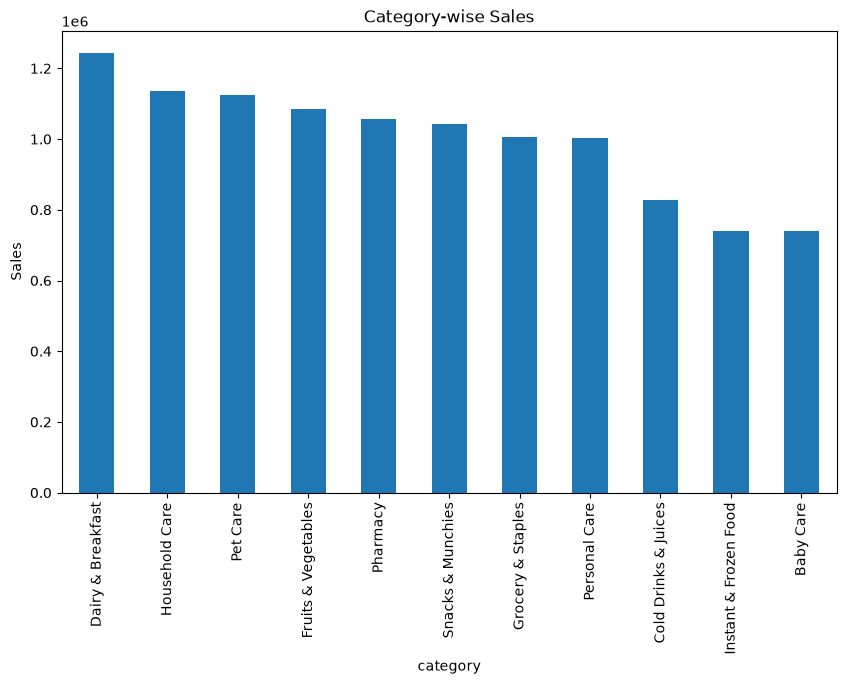

In [23]:
#8.2 Monthly Sales Trend
category_sales = (
    master_df
    .groupby("category")["order_total"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

print(category_sales)

plt.figure(figsize=(10,6))

category_sales.plot(kind="bar")

plt.title("Category-wise Sales")
plt.ylabel("Sales")

plt.show()

category
Dairy & Breakfast        1244368.69
Household Care           1136440.47
Pet Care                 1125103.80
Fruits & Vegetables      1085102.76
Pharmacy                 1055811.97
Snacks & Munchies        1043581.94
Grocery & Staples        1005494.87
Personal Care            1003163.40
Cold Drinks & Juices      828002.23
Instant & Frozen Food     741183.31
Baby Care                 741055.06
Name: order_total, dtype: float64


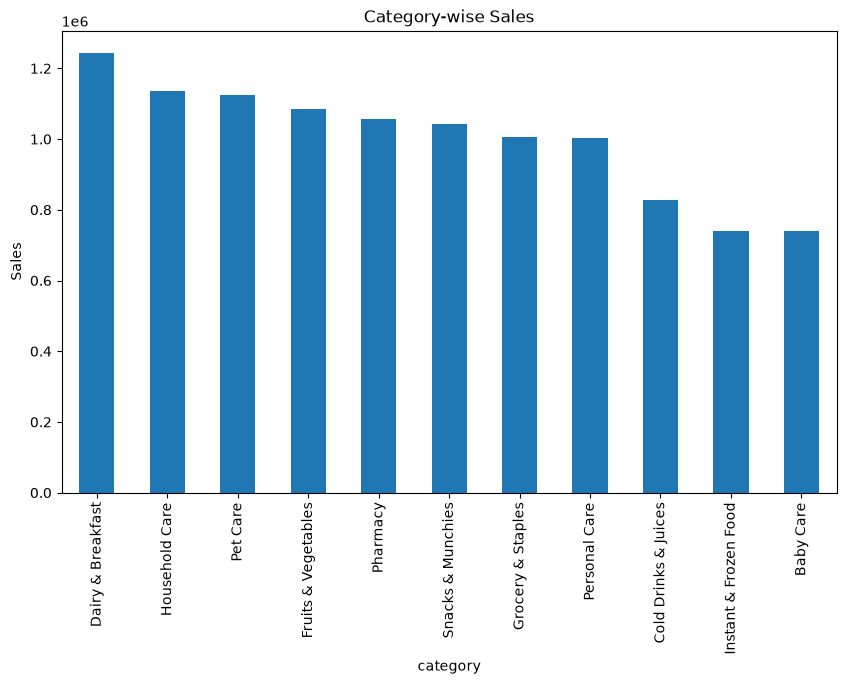

In [24]:
#8.3 Category-wise Sales
category_sales = (
    master_df
    .groupby("category")["order_total"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)
plt.figure(figsize=(10,6))

category_sales.plot(kind="bar")

plt.title("Category-wise Sales")
plt.ylabel("Sales")

plt.show()


product_name
Pet Treats        525666.31
Toilet Cleaner    434588.60
Lotion            434235.77
Dish Soap         420875.06
Cough Syrup       407824.64
Vitamins          406790.72
Baby Wipes        394356.96
Cat Food          325338.65
Pulses            311964.65
Bread             297989.26
Name: order_total, dtype: float64


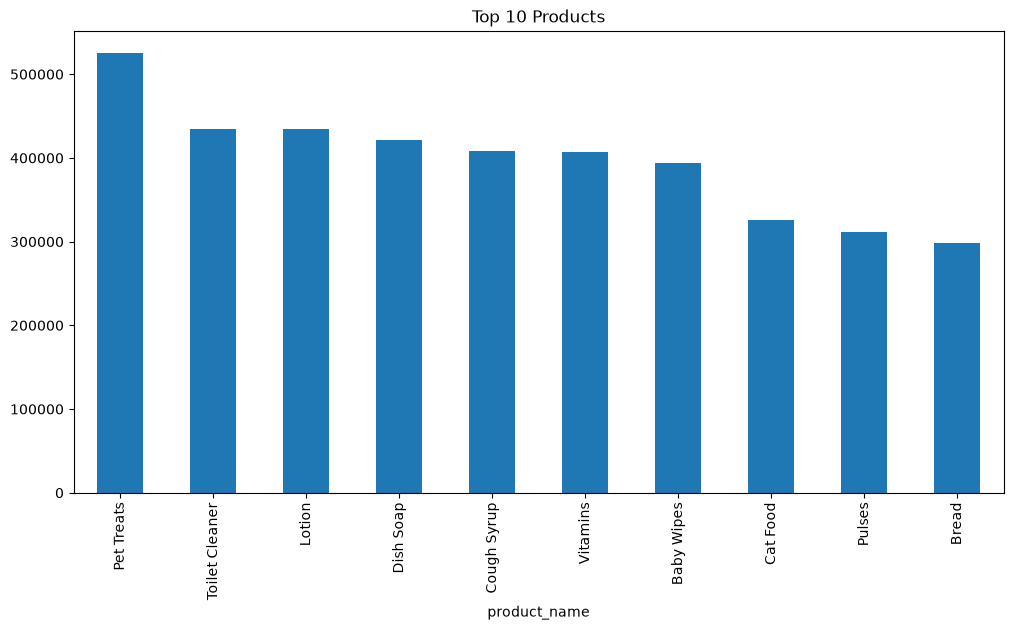

In [25]:
#8.4Top 10 Products
top_products = (
    master_df
    .groupby("product_name")["order_total"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

plt.figure(figsize=(12,6))

top_products.plot(kind="bar")

plt.title("Top 10 Products")

plt.show()


In [26]:
#85 Brand-wise Sale
brand_sales = (
    master_df
    .groupby("brand")["order_total"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(brand_sales)



brand
Mandal-Kar                 77830.82
Karnik PLC                 75330.75
Kurian-Chhabra             71356.43
Roy-Char                   70374.94
Basu and Sons              68301.33
Bahl, Jaggi and Nath       67983.86
Jha Group                  67539.27
Shroff, Wason and Dugar    65021.67
Batra, Sant and Mandal     64400.84
Morar-Mistry               63590.68
Name: order_total, dtype: float64


payment_method
Card      1285
Cash      1257
Wallet    1244
UPI       1214
Name: count, dtype: int64


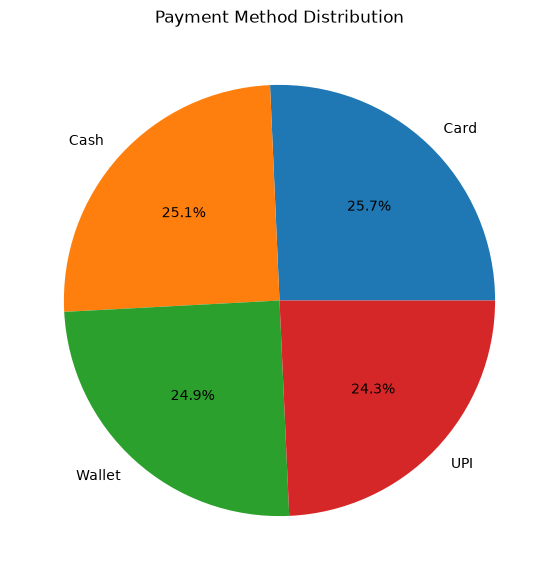

In [27]:
#8.6 Payment Method Distribution

print(master_df["payment_method"].value_counts())


plt.figure(figsize=(7,7))

master_df["payment_method"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Payment Method Distribution")

plt.show()

delivery_status
On Time                  3470
Slightly Delayed         1037
Significantly Delayed     493
Name: count, dtype: int64


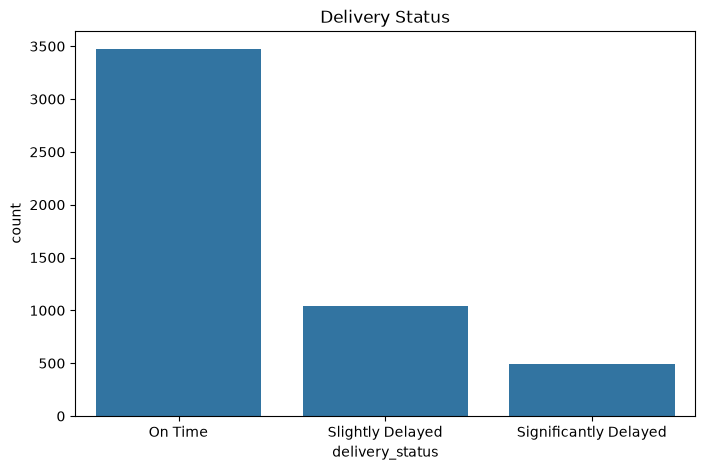

In [28]:
#8.7 Delivery Status Analysis

print(master_df["delivery_status"].value_counts())

plt.figure(figsize=(8,5))

sns.countplot(
    data=master_df,
    x="delivery_status"
)

plt.title("Delivery Status")

plt.show()

category
Dairy & Breakfast        1114
Household Care           1078
Pet Care                 1003
Pharmacy                  973
Fruits & Vegetables       966
Snacks & Munchies         963
Grocery & Staples         895
Personal Care             887
Cold Drinks & Juices      758
Instant & Frozen Food     742
Baby Care                 655
Name: quantity, dtype: int64


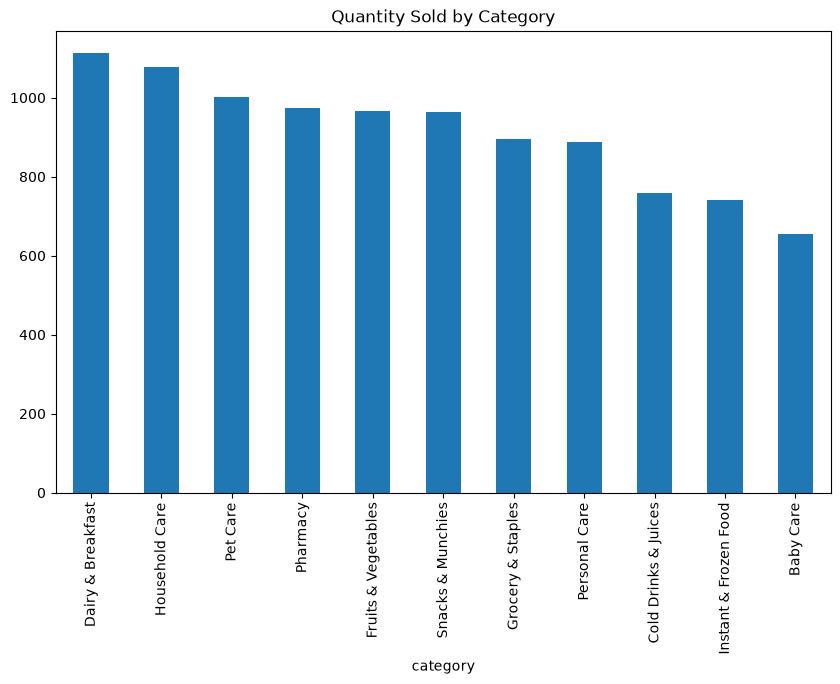

In [29]:
#8.9 Quantity Sold Analysis
quantity_analysis = (
    master_df
    .groupby("category")["quantity"]
    .sum()
    .sort_values(ascending=False)
)

print(quantity_analysis)

plt.figure(figsize=(10,6))

quantity_analysis.plot(kind="bar")

plt.title("Quantity Sold by Category")

plt.show()


## 9. Export Clean Dataset

In [30]:
# Export final cleaned dataset

master_df.to_csv(
    "../data/processed/blinkit_cleaned.csv",
    index=False
)

print("✅ Dataset exported successfully!")

✅ Dataset exported successfully!


In [31]:
# Verify exported dataset

exported_df = pd.read_csv("../data/processed/blinkit_cleaned.csv")

print(exported_df.shape)

display(exported_df.head())

(5000, 26)


,order_id,product_id,quantity,unit_price,product_name,category,brand,price,mrp,margin_percentage,...,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id,Year,Month,Weekday,Delivery_Time_Minutes
0,1961864118,642612,3,517.03,Pet Treats,Pet Care,Pillay-Ahuja,517.03,795.43,35.0,...,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771,2024,July,Wednesday,13.0
1,1549769649,378676,1,881.42,Orange Juice,Cold Drinks & Juices,Baral-Kamdar,881.42,1259.17,30.0,...,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534,2024,May,Tuesday,13.0
2,9185164487,741341,2,923.84,Eggs,Dairy & Breakfast,Prasad LLC,923.84,1154.80,20.0,...,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886,2024,September,Monday,22.0
3,9644738826,561860,1,874.78,Orange Juice,Cold Drinks & Juices,Gupta Ltd,874.78,1249.69,30.0,...,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917,2023,November,Friday,17.0
4,5427684290,602241,2,976.55,Nuts,Snacks & Munchies,Bahl-Pau,976.55,1502.38,35.0,...,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741,2023,November,Monday,18.0
